# Assignment 2: Recommender Systems

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, KNNWithMeans, SVD, accuracy
from surprise.model_selection import train_test_split

In [2]:
# Loading data
movies_raw = pd.read_csv('../assignment2-dataset/movies.csv')
ratings_train_raw = pd.read_csv('../assignment2-dataset/ratings_train.csv')

ratings_test_raw = pd.read_csv('../assignment2-dataset/ratings_test.csv')

In [3]:
# Copies of the datasets
movies = movies_raw.copy()
ratings_train = ratings_train_raw.copy()
ratings_test = ratings_test_raw.copy()

## Data Preparation and Preprocessing

In [4]:
# Inspecting datasets
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings_train.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
# Merge datasets for exploration
ratings_train_full = pd.merge(ratings_train, movies, on="movieId", how="left")
ratings_train_full.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


### Handling Missing Values

In [7]:
# Checking missing values
print(movies.isnull().sum())
print(ratings_train.isnull().sum())


print(movies.astype(str).isin(['', ' ', 'NA', 'N/A', 'null', 'None']).sum())
print(ratings_train.astype(str).isin(['', ' ', 'NA', 'N/A', 'null', 'None']).sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [8]:
# User-item matrix visualization

# Rows = users, columns = movies, values = ratings
user_item_matrix = ratings_train_full.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Analyze missing values in the user-item matrix

total_values = user_item_matrix.size
missing_values = user_item_matrix.isna().sum().sum()
observed_values = total_values - missing_values

print("Total values:", total_values)
print("Observed ratings:", observed_values)
print("Missing values:", missing_values)
print("Sparsity (%):", round(missing_values / total_values * 100, 2))
print("This confirms that the matrix is highly sparse.")

Total values: 5808000
Observed ratings: 97801
Missing values: 5710199
Sparsity (%): 98.32
This confirms that the matrix is highly sparse.


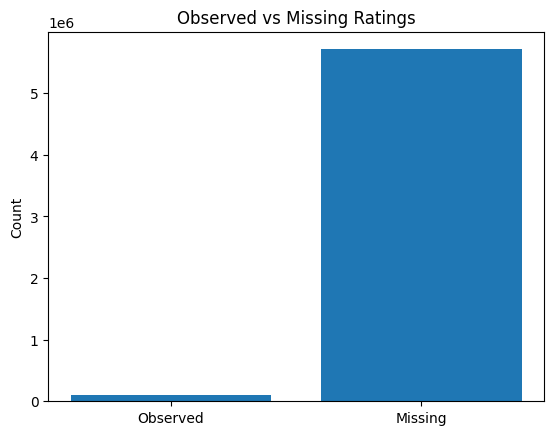

In [10]:
plt.bar(["Observed", "Missing"], [observed_values, missing_values])
plt.title("Observed vs Missing Ratings")
plt.ylabel("Count")
plt.show()

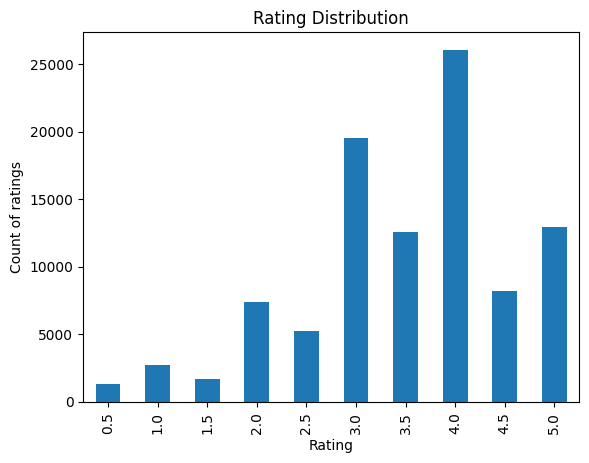

In [11]:
# Visualization of rating distribution
ratings_train["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count of ratings")
plt.show()

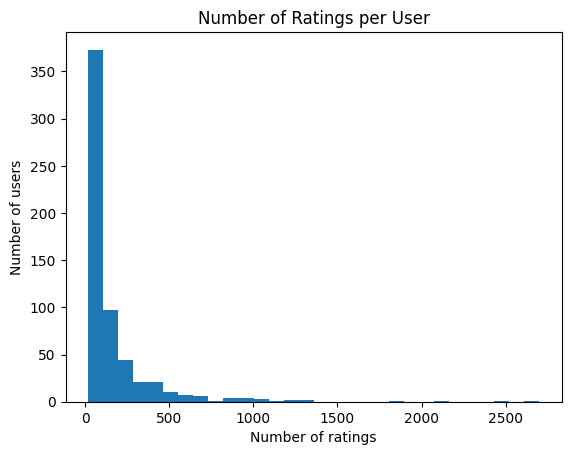

In [12]:
ratings_per_user = ratings_train.groupby("userId")["rating"].count()

ratings_per_user.plot(kind="hist", bins=30)
plt.title("Number of Ratings per User")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")
plt.show()

### Normalization of Numerical Attributes
Normalization is shown for illustration because models handle it internally.

In [13]:
# User mean rating 
user_mean = ratings_train.groupby("userId")["rating"].mean()
print(user_mean.head())

userId
1    4.366379
2    3.948276
3    2.368421
4    3.555556
5    3.636364
Name: rating, dtype: float64


In [14]:
# Example of normalization 
user_item_norm = user_item_matrix.sub(user_item_matrix.mean(axis=1), axis=0)
user_item_norm.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,NaN,-0.366379,NaN,NaN,-0.366379,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.363636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Encoding Categorical Features
Encoding is shown for illustration because collaborative filtering models do not use these features.

In [15]:
# Genres before encoding
print(ratings_train_full[["movieId", "genres"]].head())

   movieId                                       genres
0        1  Adventure|Animation|Children|Comedy|Fantasy
1        3                               Comedy|Romance
2        6                        Action|Crime|Thriller
3       47                             Mystery|Thriller
4       50                       Crime|Mystery|Thriller


In [16]:
# Example of genre encoding
genres_encoded = ratings_train_full["genres"].str.get_dummies(sep="|")
genres_encoded.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


## Task 1: Building Recommender Models

In [17]:
ratings_train.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [18]:
# Preparing data for Surprise

# rating scale from dataset
reader = Reader(rating_scale=(ratings_train["rating"].min(), ratings_train["rating"].max()))

# keep only userId, movieId, rating
data = Dataset.load_from_df(
    ratings_train[["userId", "movieId", "rating"]],
    reader
)

# split data into train and validation
trainset, valset = train_test_split(data, test_size=0.2, random_state=10)

### Collaborative Filtering (User-Based)

In [19]:
sim_options = {
    "name": "cosine",
    "user_based": True
}

knn_model = KNNWithMeans(sim_options=sim_options)
knn_model.fit(trainset)

knn_predictions = knn_model.test(valset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [20]:
# Convert predictions to DataFrame (visualization purposes)

pred_rows = []

for pred in knn_predictions:
    pred_rows.append({
        "userId": pred.uid,
        "movieId": pred.iid,
        "true_rating": pred.r_ui,
        "predicted_rating": pred.est
    })

pred_df = pd.DataFrame(pred_rows)

pred_df.head()

,userId,movieId,true_rating,predicted_rating
0,367,3512,4.0,3.721254
1,331,54272,3.0,3.697608
2,305,145418,4.0,3.505835
3,438,5378,3.5,3.094831
4,8,590,5.0,3.662737


### Matrix Factorization

In [21]:
# Train SVD model
svd_model = SVD(random_state=10)
svd_model.fit(trainset)

# Predict ratings on validation set
svd_predictions = svd_model.test(valset)

In [22]:
# User factors (P)
P = svd_model.pu

# Item factors (Q)
Q = svd_model.qi

print("Shape of P (users x factors):", P.shape)
print("Shape of Q (items x factors):", Q.shape)

Shape of P (users x factors): (600, 100)
Shape of Q (items x factors): (8911, 100)


In [23]:
# Reconstruct estimated rating matrix for visualization
R_hat = np.dot(P, Q.T)

In [24]:
# Map Surprise internal ids back to original ids
user_ids = [trainset.to_raw_uid(u) for u in range(trainset.n_users)]
item_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]

R_hat_df = pd.DataFrame(R_hat, index=user_ids, columns=item_ids)

# Small preview of predicted ratings
R_hat_df.iloc[:5, :5]

,1801,4816,1951,736,1573
452,-0.014501,-0.074428,0.015712,-0.067357,0.046234
534,-0.062002,-0.063418,-0.150783,0.090762,0.001702
474,-0.085126,-0.006489,0.072850,0.019241,0.344283
170,-0.048729,-0.046498,-0.148422,-0.008127,0.059620
561,0.114726,0.055371,0.274328,0.009509,-0.098657


### Evaluating the Models

#### Root Mean Squared Error (RMSE)
RMSE helps us understand how far our predictions are from the real ratings. A lower value means the model is making better predictions, since it is closer to what users actually rated.

More details: https://surprise.readthedocs.io/en/stable/accuracy.html

In [25]:
# Evaluate both models with RMSE
print("KNNWithMeans RMSE:")
knn_rmse = accuracy.rmse(knn_predictions)

print("\nSVD RMSE:")
svd_rmse = accuracy.rmse(svd_predictions)

KNNWithMeans RMSE:
RMSE: 0.8970

SVD RMSE:
RMSE: 0.8672


Predictions are first converted into a table with `predictions_to_df`. Then, top-k recommendations per user are selected using `get_top_k`. Relevant items are defined as those with ratings ≥ 4 using `build_test_out`. Finally, recommendations are compared with relevant items to compute Precision@K and Recall@K.

In [26]:
# Convert Surprise predictions into a DataFrame
def predictions_to_df(predictions):
    rows = []

    for pred in predictions:
        rows.append({
            "user_id": pred.uid,
            "item_id": pred.iid,
            "score": pred.est
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["user_id", "score"], ascending=[True, False])
    df = df.reset_index(drop=True)

    return df

In [27]:
# Processes the recommendations so that, for each user, only the first *k* unique items are kept.
def get_top_k(predictions_df, k):
    return (
        predictions_df
        .drop_duplicates(["user_id", "item_id"])
        .groupby("user_id")
        .head(k)
        .reset_index(drop=True)
    )

In [28]:
# Build the relevant items from the validation set (ratings >= 4 are considered as relevant)
def build_test_out(valset):
    rows = []

    for user_id, item_id, true_rating in valset:
        if true_rating >= 4:
            rows.append({
                "user_id": user_id,
                "item_id": item_id
            })

    return pd.DataFrame(rows)

#### Recall@K

Recall@K checks how many relevant items appear in the top-k recommendations.

Here we use a calibrated version, where hits are divided by the maximum possible hits (min(k, relevant items)). This avoids penalizing the model when there are more relevant items than recommendations.

The final value is the average across users. Higher is better.

More details: https://recpack.froomle.ai/generated/recpack.metrics.CalibratedRecallK.html

In [29]:
# Calculate Recall@K using calibrated recall
def calculate_recall_at_k(predictions_df, test_out_df, k):
    top_k = get_top_k(predictions_df, k)

    hits = pd.merge(top_k, test_out_df, on=["user_id", "item_id"])
    hits_per_user = hits["user_id"].value_counts()

    relevant_per_user = test_out_df["user_id"].value_counts()
    max_possible_hits = relevant_per_user.clip(upper=k)

    # Reindex hits over ALL users that have at least one relevant item
    hits_per_user = hits_per_user.reindex(max_possible_hits.index, fill_value=0)

    recall_per_user = hits_per_user / max_possible_hits

    return recall_per_user.mean()

#### Precision@K
This function computes Precision@K, which measures how many of the top-k recommended items are relevant. It selects the top-k items per user, compares them with relevant items, computes hits/k, and returns the average across users.

In [30]:
# Calculate Precision@K
def calculate_precision_at_k(predictions_df, test_out_df, k):
    top_k = get_top_k(predictions_df, k)

    hits = pd.merge(top_k, test_out_df, on=["user_id", "item_id"])
    hits_per_user = hits["user_id"].value_counts()

    all_users = top_k["user_id"].unique()
    hits_per_user = hits_per_user.reindex(all_users, fill_value=0)

    precision_per_user = hits_per_user / k

    return precision_per_user.mean()

#### Diversity
This metric measures what fraction of the movie catalog gets recommended across all users. A model that always recommends the same popular movies will have a low diversity score, while a model that explores the catalog will score higher.

In [31]:
# Item Coverage (catalog coverage)
def calculate_diversity_at_k(predictions_df, total_movies, k):
    top_k = get_top_k(predictions_df, k)
    unique_movies = top_k["item_id"].nunique()

    return unique_movies / total_movies

#### Novelty
This metric measures how uncommon the recommended items are, based on their popularity. Less frequent items are considered more novel. Higher values indicate more surprising recommendations.

In [32]:
# Calculate Novelty@K based on item popularity
def calculate_novelty_at_k(predictions_df, train_df, k):
    top_k = get_top_k(predictions_df, k).copy()

    item_popularity = train_df["movieId"].value_counts()
    total_interactions = len(train_df)

    top_k["popularity"] = top_k["item_id"].map(item_popularity)
    top_k["novelty"] = -np.log2(top_k["popularity"] / total_interactions)

    novelty_per_user = top_k.groupby("user_id")["novelty"].mean()

    return novelty_per_user.mean()

In [33]:
# Predictions to DataFrame
knn_pred_df = predictions_to_df(knn_predictions)
svd_pred_df = predictions_to_df(svd_predictions)

# Set of relevant items from the validation data (ratings ≥ 4).
test_out_df = build_test_out(valset)

# Calculate Recall@10
knn_recall = calculate_recall_at_k(knn_pred_df, test_out_df, 10)
svd_recall = calculate_recall_at_k(svd_pred_df, test_out_df, 10)

print("KNNWithMeans Recall@10:", round(knn_recall, 4))
print("SVD Recall@10:", round(svd_recall, 4))

# Calculate Precision@10
knn_precision = calculate_precision_at_k(knn_pred_df, test_out_df, 10)
svd_precision = calculate_precision_at_k(svd_pred_df, test_out_df, 10)

print("KNNWithMeans Precision@10:", round(knn_precision, 4))
print("SVD Precision@10:", round(svd_precision, 4))

# Total number of movies
total_movies = ratings_train["movieId"].nunique()

# Calculate Diversity@10
knn_diversity = calculate_diversity_at_k(knn_pred_df, total_movies, 10)
svd_diversity = calculate_diversity_at_k(svd_pred_df, total_movies, 10)

print("KNNWithMeans Diversity@10:", round(knn_diversity, 4))
print("SVD Diversity@10:", round(svd_diversity, 4))

# Calculate Novelty@10
knn_novelty = calculate_novelty_at_k(knn_pred_df, ratings_train, 10)
svd_novelty = calculate_novelty_at_k(svd_pred_df, ratings_train, 10)

print("KNNWithMeans Novelty@10:", round(knn_novelty, 4))
print("SVD Novelty@10:", round(svd_novelty, 4))

KNNWithMeans Recall@10: 0.8391
SVD Recall@10: 0.8573
KNNWithMeans Precision@10: 0.5426
SVD Precision@10: 0.5606
KNNWithMeans Diversity@10: 0.1748
SVD Diversity@10: 0.1388
KNNWithMeans Novelty@10: 10.967
SVD Novelty@10: 10.5243


### Comparison of models

In [34]:
# Compare the models
results = pd.DataFrame({
    "Model": ["KNNWithMeans", "SVD"],
    "RMSE": [knn_rmse, svd_rmse],
    "Precision@10": [knn_precision, svd_precision],
    "Recall@10": [knn_recall, svd_recall],
    "Diversity@10": [knn_diversity, svd_diversity],
    "Novelty@10": [knn_novelty, svd_novelty]
})
results

,Model,RMSE,Precision@10,Recall@10,Diversity@10,Novelty@10
0,KNNWithMeans,0.897003,0.542571,0.839069,0.174793,10.967006
1,SVD,0.867197,0.560601,0.857285,0.138843,10.524298


The model with the lower RMSE is the best one. This variable is stored and later used to train the model depending on the result obtained here.

In [35]:
# Best model using RMSE
if knn_rmse < svd_rmse:
    best_model_name = "KNNWithMeans"
else:
    best_model_name = "SVD"

print("Best model:", best_model_name)

Best model: SVD


Different plots to compare them and see the differences between them.
The difference in RMSE is small, suggesting that both models perform almost equally in terms of accuracy

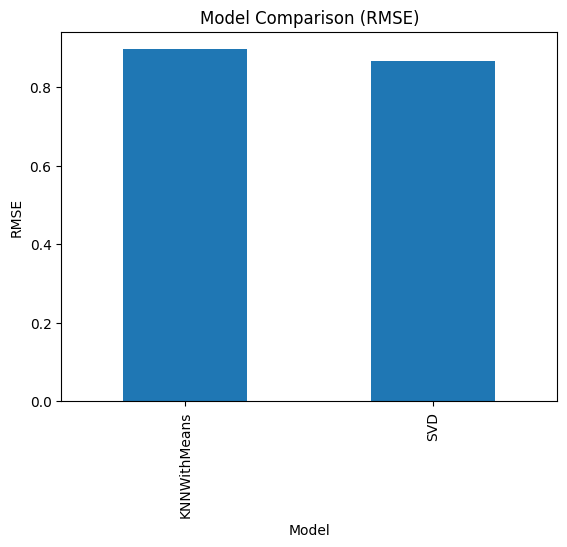

In [36]:
results.set_index("Model")["RMSE"].plot(kind="bar")
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

The results show that both models have very similar performance in precision, recall, and diversity.

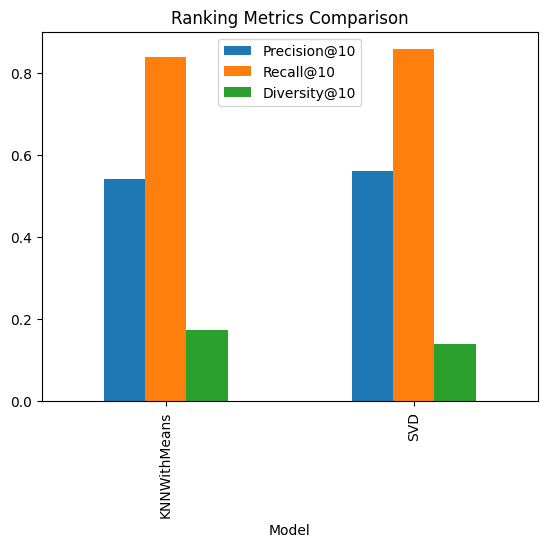

In [37]:
results.set_index("Model")[["Precision@10", "Recall@10", "Diversity@10"]].plot(kind="bar")
plt.title("Ranking Metrics Comparison")
plt.show()

The difference in novelty is small, but KNNWithMeans tends to provide more novel recommendations than SVD

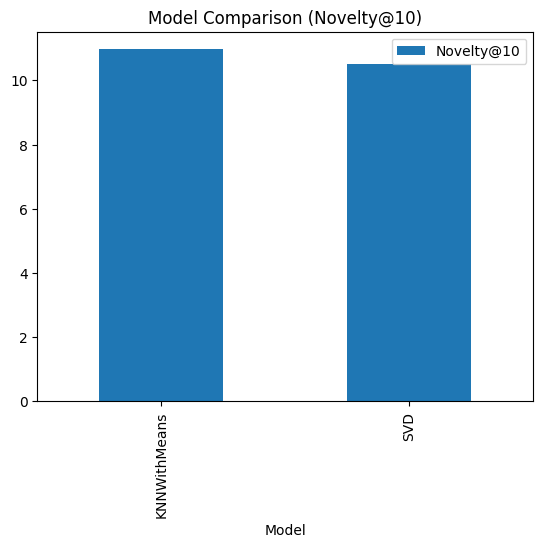

In [38]:
results.set_index("Model")[["Novelty@10"]].plot(kind="bar")
plt.title("Model Comparison (Novelty@10)")
plt.show()

## Task 2: Generate Recommendations for ratings_test.csv

### Cold cases (new users that have no interactions yet)

SVD model is selected as the best-performing model because it achieves the lowest RMSE, which indicates better prediction accuracy, also it shows slightly higher precision and recall compared to KNNWithMeans

Analysis to identify cold-start users, who have no prior interactions. For these users, a popularity-based recommendation strategy is applied.

Total test users: 100
Known users: 90
Cold-start users: 10
Cold-start percentage: 10.0 %


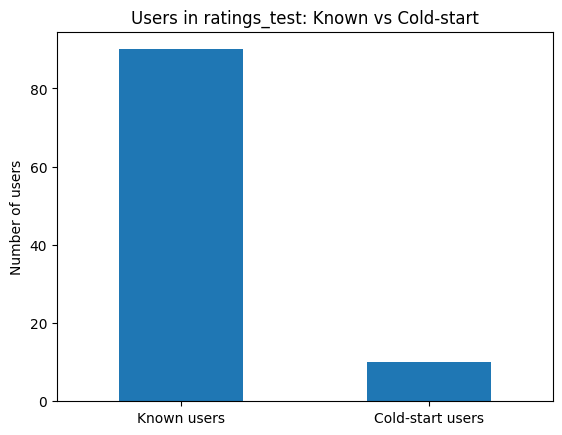

In [39]:
train_users = set(ratings_train["userId"].unique())
test_users = set(ratings_test["userId"].unique())

cold_users = test_users - train_users
known_users = test_users & train_users

print("Total test users:", len(test_users))
print("Known users:", len(known_users))
print("Cold-start users:", len(cold_users))
print("Cold-start percentage:", round(len(cold_users) / len(test_users) * 100, 2), "%")

cold_case_counts = pd.Series({
    "Known users": len(known_users),
    "Cold-start users": len(cold_users)
})

cold_case_counts.plot(kind="bar")
plt.title("Users in ratings_test: Known vs Cold-start")
plt.ylabel("Number of users")
plt.xticks(rotation=0)
plt.show()

As mentioned before, a popularity-based recommendation strategy is applied for these users. To do this, we identified the highest-rated films.

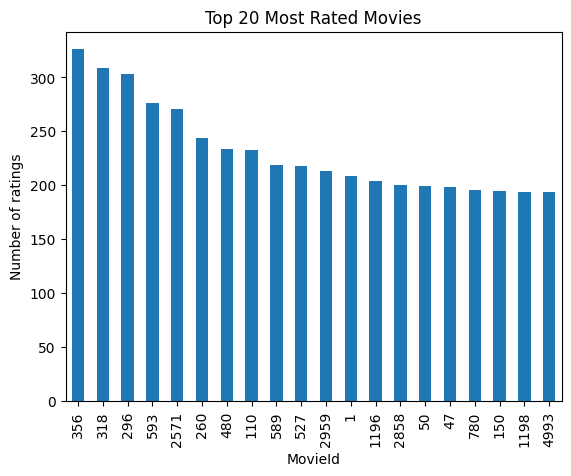

In [40]:
popular_counts = ratings_train["movieId"].value_counts()

popular_counts.head(20).plot(kind="bar")
plt.title("Top 20 Most Rated Movies")
plt.xlabel("MovieId")
plt.ylabel("Number of ratings")
plt.show()

In [41]:
# Build a simple popularity list for cold-start users
popular_movies = (
    ratings_train.groupby("movieId")["rating"]
    .count()
    .sort_values(ascending=False)
    .index
    .tolist()
)

### Personalized Recommendations (Best Model)

In [42]:
# Build full training set
full_trainset = data.build_full_trainset()

# Select best model
if best_model_name == "KNNWithMeans":
    best_model = KNNWithMeans(sim_options=sim_options)
else:
    best_model = SVD(random_state=10)

# Train model on all data
best_model.fit(full_trainset)

In [43]:
# All users in training data
train_users = set(ratings_train["userId"].unique())

# All movies in training data
train_movies = set(ratings_train["movieId"].unique())

# Dictionary for seen movies per user
user_seen_movies = {}

# Store movies already seen by each user
for user_id, movie_list in ratings_train.groupby("userId")["movieId"]:
    user_seen_movies[user_id] = set(movie_list)

In [44]:
# Recommend top-k movies for one user
def recommend_top_k(user_id, model, k=10):
    recommendations = []

    # Movies already seen by the user
    if user_id in user_seen_movies:
        seen_movies = user_seen_movies[user_id]
    else:
        seen_movies = set()

    # Cold-start user: recommend popular movies
    if user_id not in train_users:
        for movie_id in popular_movies:
            if movie_id not in seen_movies:
                recommendations.append(movie_id)

            if len(recommendations) == k:
                break

        return recommendations

    # Known user: predict scores for unseen movies
    candidate_movies = []

    for movie_id in train_movies:
        if movie_id not in seen_movies:
            predicted_score = model.predict(user_id, movie_id).est
            candidate_movies.append((movie_id, predicted_score))

    # Sort candidate movies based on predicted ratings so the best recommendations come first
    candidate_movies.sort(key=lambda x: x[1], reverse=True)

    for movie_id, predicted_score in candidate_movies[:k]:
        recommendations.append(movie_id)

    return recommendations

In [45]:
# Example recommendations with titles for one user
user = ratings_test["userId"].iloc[0]
movie_titles = movies.set_index("movieId")["title"].to_dict()

recommendations = recommend_top_k(user, best_model, 10)

print(f"User {user} recommendations:")
for movie_id in recommendations:
    print(movie_id, "-", movie_titles.get(movie_id, "Unknown"))

User 3 recommendations:
58559 - Dark Knight, The (2008)
1247 - Graduate, The (1967)
541 - Blade Runner (1982)
89492 - Moneyball (2011)
1203 - 12 Angry Men (1957)
91529 - Dark Knight Rises, The (2012)
1210 - Star Wars: Episode VI - Return of the Jedi (1983)
68157 - Inglourious Basterds (2009)
27773 - Old Boy (2003)
1197 - Princess Bride, The (1987)


### Top 10 Recommendations per User (CSV Output)

In [46]:
# Fill the test file with 10 recommendations per user
rows = []

for user_id in ratings_test["userId"]:
    recs = recommend_top_k(user_id, best_model, 10)

    row = {
        "userId": user_id,
        "recommendation1": recs[0],
        "recommendation2": recs[1],
        "recommendation3": recs[2],
        "recommendation4": recs[3],
        "recommendation5": recs[4],
        "recommendation6": recs[5],
        "recommendation7": recs[6],
        "recommendation8": recs[7],
        "recommendation9": recs[8],
        "recommendation10": recs[9]
    }

    rows.append(row)

submission = pd.DataFrame(rows)
submission.head()

,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,58559,1247,541,89492,1203,91529,1210,68157,27773,1197
1,7,1148,908,4973,1136,1265,1080,527,1288,246,1201
2,11,1204,3578,858,750,898,1250,1267,1262,930,912
3,25,50,246,296,318,356,741,750,858,866,898
4,30,296,858,898,1199,1204,1207,1208,1213,1221,1223


In [47]:
# Save the final csv
submission.to_csv("ratings_test_filled.csv", index=False)

print("File saved as ratings_test_filled.csv")

File saved as ratings_test_filled.csv
